In [3]:
import pandas as pd
import numpy as np
import re, string, warnings, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack
from sentence_transformers import SentenceTransformer
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings('ignore')


In [4]:
# Data Loading
df = pd.read_csv(r"C:\Users\asnav\OneDrive\Documents\MachineLearningProjects\resume_sreening\data\resume_jd_dataset.csv")
df.head()

,resume_str,jd_str,label
0,Summary Competent and reliable professional...,agency civil service department of\n\ntitle te...,1
1,Professional Overview Results-oriented Sal...,\n\nminimum level of education\nhigh school or...,0
2,Summary Seeking an employment position in t...,requisition no \n\nagency economic opportunity...,1
3,Summary Experienced sales supervisor and r...,\n\nminimum level of education\nhigh school or...,1
4,Summary Results-oriented digital marketing ...,position overview\n\nthe product sales analys...,0


In [5]:
df = df[['resume_str', 'jd_str', 'label']].dropna()

In [ ]:
# Text Cleaning
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return ' '.join(words)

df['Resume'] = df['resume_str'].apply(clean_text)
df['Job_Description'] = df['jd_str'].apply(clean_text)
df['combined_text'] = df['Resume'] + ' ' + df['Job_Description']


[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


In [ ]:
# Feature Engineering
# Length features
df['resume_len'] = df['Resume'].apply(lambda x: len(x.split()))
df['jd_len'] = df['Job_Description'].apply(lambda x: len(x.split()))
df['len_ratio'] = df['resume_len'] / (df['jd_len'] + 1)

In [ ]:
# TF-IDF cosine similarity
vectorizer_temp = TfidfVectorizer(max_features=15000)
jd_vecs = vectorizer_temp.fit_transform(df['Job_Description'])
res_vecs = vectorizer_temp.transform(df['Resume'])
df['tfidf_similarity'] = [
    cosine_similarity(res_vecs[i], jd_vecs[i])[0][0] for i in range(len(df))
]

In [ ]:
# BERT semantic similarity
bert = SentenceTransformer('all-MiniLM-L6-v2')
resume_emb = bert.encode(df['Resume'].tolist(), show_progress_bar=True)
jd_emb = bert.encode(df['Job_Description'].tolist(), show_progress_bar=True)
df['bert_similarity'] = [cosine_similarity([resume_emb[i]], [jd_emb[i]])[0][0] for i in range(len(df))]


Batches:  52%|█████▏    | 203/389 [05:24<04:57,  1.60s/it]


KeyboardInterrupt: 

In [ ]:
# Reduce BERT dimensions for memory efficiency
svd = TruncatedSVD(n_components=50, random_state=42)
bert_combined = np.hstack([resume_emb, jd_emb])
bert_reduced = svd.fit_transform(bert_combined)

In [ ]:
# TF-IDF Vectorization + Structured Merge
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=15000)
X_text = vectorizer.fit_transform(df['combined_text'])
X_structured = df[['resume_len', 'len_ratio', 'tfidf_similarity', 'bert_similarity']].values
X = hstack([X_text, X_structured, bert_reduced])
y = df['label'].values

NameError: name 'TfidfVectorizer' is not defined

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


✅ Tuned Random Forest Accuracy: 72.76%
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 500}

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.76      0.77      2236
           1       0.66      0.67      0.66      1490

    accuracy                           0.73      3726
   macro avg       0.72      0.72      0.72      3726
weighted avg       0.73      0.73      0.73      3726



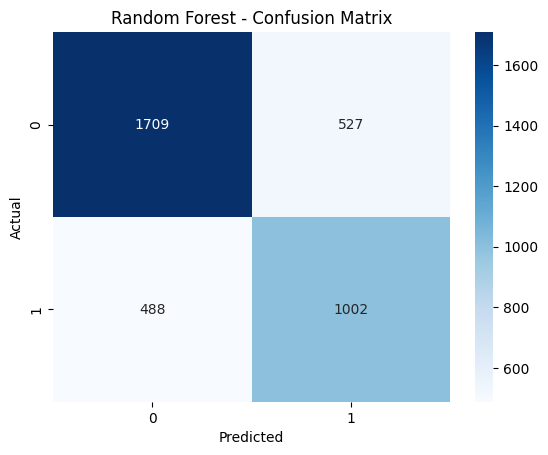

In [ ]:
# hyperparameter grid (commented to save time)
# param_grid = {
#     'n_estimators': [200, 300, 500],
#     'max_depth': [20, 30],
#     'min_samples_split': [5, 10],
#     'min_samples_leaf': [1, 2],
#     'max_features': ['sqrt', 'log2']
# }
#
# grid_search = GridSearchCV(
#     estimator=RandomForestClassifier(random_state=42),
#     param_grid=param_grid,
#     cv=3,
#     n_jobs=-1,
#     verbose=1,
#     scoring='accuracy'
# )
# grid_search.fit(X_train, y_train)
# best_rf = grid_search.best_estimator_

# Using best parameters directly
best_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

# Fit model
best_rf.fit(X_train, y_train)

# Predict
y_pred_rf = best_rf.predict(X_test)

# Accuracy
rf_acc = round(accuracy_score(y_test, y_pred_rf) * 100, 2)
print(f"\n✅ Tuned Random Forest Accuracy: {rf_acc}%")

# Best parameters display
print("Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 500}")

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# # Ensemble Models (Weighted Voting + Stacking)
# # Tuned XGBoost
# xgb = XGBClassifier(
#     n_estimators=200,      # fewer trees
#     max_depth=6,           # shallower trees
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     scale_pos_weight=df['label'].value_counts()[0]/df['label'].value_counts()[1],
#     use_label_encoder=False,
#     eval_metric='logloss',
#     tree_method='hist',
#     random_state=42
# )
# xgb.fit(X_train, y_train)


In [ ]:
# voting_clf = VotingClassifier(
#     estimators=[('rf', best_rf), ('xgb', xgb)],
#     voting='hard',  # hard voting uses less memory than soft
#     weights=[2, 1]  # RF stronger
# )

# voting_clf.fit(X_train, y_train)
# y_pred_vote = voting_clf.predict(X_test)

# vote_acc = round(accuracy_score(y_test, y_pred_vote) * 100, 2)
# print(f"\n🧠 Weighted Voting Ensemble Accuracy: {vote_acc}%")
# print("\nClassification Report:\n", classification_report(y_test, y_pred_vote))

In [ ]:
# # Confusion Matrix
# cm_vote = confusion_matrix(y_test, y_pred_vote)
# sns.heatmap(cm_vote, annot=True, fmt='d', cmap='Blues')
# plt.title("Weighted Voting Ensemble - Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

In [ ]:
# stacking_clf = StackingClassifier(
#     estimators=[('rf', best_rf), ('lr', LogisticRegression(max_iter=1000))],
#     final_estimator=LogisticRegression(max_iter=1000)
# )

# stacking_clf.fit(X_train, y_train)
# y_pred_stack = stacking_clf.predict(X_test)

# stack_acc = round(accuracy_score(y_test, y_pred_stack) * 100, 2)
# print(f"\n🔗 Stacking Ensemble Accuracy: {stack_acc}%")
# print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))

In [ ]:
# # Confusion Matrix
# cm_vote = confusion_matrix(y_test, y_pred_stack)
# sns.heatmap(cm_vote, annot=True, fmt='d', cmap='Blues')
# plt.title("Weighted Voting Ensemble - Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

In [ ]:
# # Accuracy Comparison
# results = pd.DataFrame({
#     'Model': ['Random Forest (Tuned)', 'Weighted Voting Ensemble', 'Stacking Ensemble'],
#     'Accuracy (%)': [rf_acc, vote_acc, stack_acc]
# })
# print("\n📊 Model Performance Comparison:")
# print(results)

In [ ]:
# Example prediction
sample_index = 0
print("\n🔍 Sample Prediction:")
print("Predicted:", y_pred_rf[sample_index])
print("Actual:", y_test[sample_index])


🔍 Sample Prediction:
Predicted: 1
Actual: 1


In [ ]:
import pickle
pickle.dump(best_rf, open('model.pkl', 'wb'))
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))